# WEEK 7 - DATA 56000
## Assignment #7: CNN-Based Digital Image Segmentation
**Pol Monne Parera (L30170743)**  
pmonneparera@lewisu.edu  
Spring 2026

### 1. Imports

In [58]:
%pip install torch torchvision torchaudio

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import image as mpimg
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
IMAGE_SIZE = (160, 160)

Note: you may need to restart the kernel to use updated packages.


### 2. Load the Three Source Images

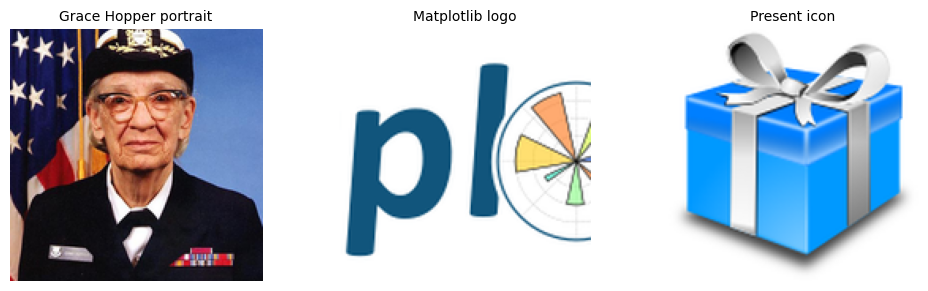

In [60]:
def resize_rgb(arr, image_size=IMAGE_SIZE):
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.shape[-1] == 4:
        alpha = arr[..., 3:4]
        rgb = arr[..., :3]
        arr = rgb * alpha + (1.0 - alpha)
    if arr.dtype != np.float32 and arr.dtype != np.float64:
        arr = arr.astype(np.float32) / 255.0
    pil = Image.fromarray((np.clip(arr[..., :3], 0, 1) * 255).astype(np.uint8)).convert("RGB")
    pil = ImageOps.fit(pil, image_size, Image.Resampling.LANCZOS)
    return np.asarray(pil).astype(np.float32) / 255.0

def rgb_to_gray(rgb):
    return np.dot(rgb[..., :3], np.array([0.299, 0.587, 0.114], dtype=np.float32))

sample_dir = Path(plt.matplotlib.get_data_path()) / "sample_data"
source_items = [
    ("grace_hopper", "Grace Hopper portrait", sample_dir / "grace_hopper.jpg", "dark_foreground"),
    ("matplotlib_logo", "Matplotlib logo", sample_dir / "logo2.png", "dark_foreground"),
]

present_rgb = resize_rgb(mpimg.imread(sample_dir / "Minduka_Present_Blue_Pack.png"))

images = []
for image_id, title, path, strategy in source_items:
    rgb = resize_rgb(mpimg.imread(path))
    images.append({"id": image_id, "title": title, "strategy": strategy, "rgb": rgb})
images.append({"id": "present_icon", "title": "Present icon", "strategy": "dark_foreground", "rgb": present_rgb})

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, item in zip(axes, images):
    ax.imshow(item["rgb"])
    ax.set_title(item["title"], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3. Create Synthetic Segmentation Labels

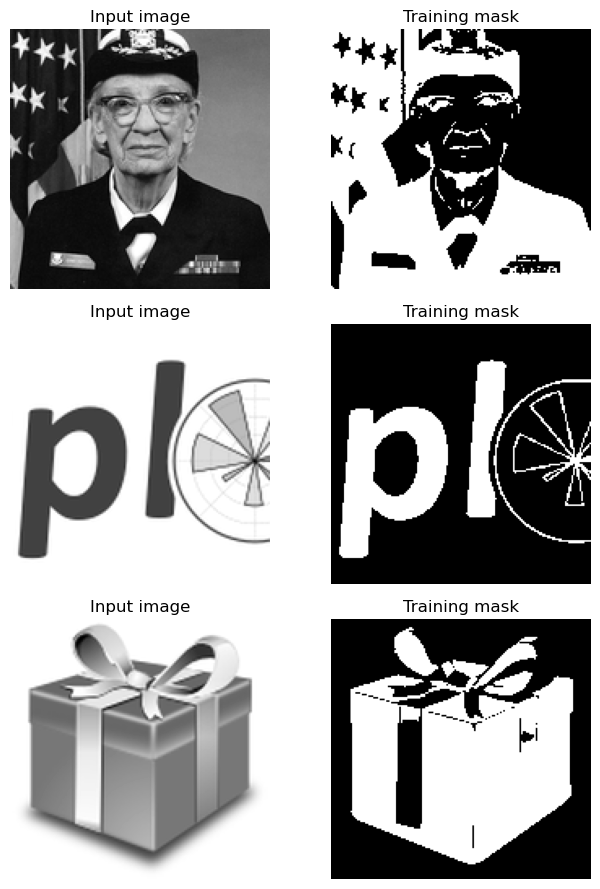

In [62]:
def otsu_threshold(gray):
    values = np.clip((gray * 255).astype(np.uint8), 0, 255)
    hist, _ = np.histogram(values.ravel(), bins=256, range=(0, 256))
    total = values.size
    sum_total = np.dot(np.arange(256), hist)
    weight_bg = 0.0
    sum_bg = 0.0
    best_var = -1.0
    best_thresh = 127
    for threshold in range(256):
        weight_bg += hist[threshold]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        sum_bg += threshold * hist[threshold]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        between_var = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if between_var > best_var:
            best_var = between_var
            best_thresh = threshold
    return best_thresh / 255.0

def make_mask(gray, strategy):
    if strategy == "dark_foreground":
        return (gray < otsu_threshold(gray)).astype(np.float32)
    if strategy == "mid_high":
        return (gray > np.quantile(gray, 0.58)).astype(np.float32)
    raise ValueError(strategy)

for item in images:
    item["gray"] = rgb_to_gray(item["rgb"])
    item["mask"] = make_mask(item["gray"], item["strategy"])

fig, axes = plt.subplots(3, 2, figsize=(7, 9))
for row, item in enumerate(images):
    axes[row, 0].imshow(item["gray"], cmap="gray")
    axes[row, 0].set_title("Input image")
    axes[row, 1].imshow(item["mask"], cmap="gray")
    axes[row, 1].set_title("Training mask")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 4. Build the Augmented Training Set

In [64]:
def shift_image(arr, dy, dx):
    shifted = np.roll(arr, shift=(dy, dx), axis=(-2, -1))
    if dy > 0:
        shifted[..., :dy, :] = 0
    elif dy < 0:
        shifted[..., dy:, :] = 0
    if dx > 0:
        shifted[..., :, :dx] = 0
    elif dx < 0:
        shifted[..., :, dx:] = 0
    return shifted

def augment_pair(image, mask):
    x = image.copy()
    y = mask.copy()
    if random.random() < 0.5:
        x = np.flip(x, axis=1)
        y = np.flip(y, axis=1)
    if random.random() < 0.5:
        x = np.flip(x, axis=0)
        y = np.flip(y, axis=0)
    k = random.randint(0, 3)
    x = np.rot90(x, k, axes=(0, 1))
    y = np.rot90(y, k, axes=(0, 1))
    dy = random.randint(-8, 8)
    dx = random.randint(-8, 8)
    x = shift_image(x[None, ...], dy, dx)[0]
    y = shift_image(y[None, ...], dy, dx)[0]
    x = np.clip(x + np.random.normal(0, 0.025, size=x.shape), 0.0, 1.0)
    return x.astype(np.float32), y.astype(np.float32)

train_x, train_y = [], []
for item in images:
    train_x.append(item["gray"])
    train_y.append(item["mask"])
    for _ in range(120):
        aug_x, aug_y = augment_pair(item["gray"], item["mask"])
        train_x.append(aug_x)
        train_y.append(aug_y)

train_x = torch.tensor(np.array(train_x)[:, None, :, :], dtype=torch.float32)
train_y = torch.tensor(np.array(train_y)[:, None, :, :], dtype=torch.float32)
loader = DataLoader(TensorDataset(train_x, train_y), batch_size=12, shuffle=True)
print(train_x.shape, train_y.shape)

torch.Size([363, 1, 160, 160]) torch.Size([363, 1, 160, 160])


### 5. CNN Model

In [66]:
class SmallSegmentationCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(16, 1, kernel_size=1),
        )

    def forward(self, x):
        return self.network(x)

model = SmallSegmentationCNN()
print(model)

SmallSegmentationCNN(
  (network): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Upsample(scale_factor=2.0, mode='bilinear')
    (9): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): Upsample(scale_factor=2.0, mode='bilinear')
    (12): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


### 6. Train the CNN

Epoch 01: loss=0.6551
Epoch 05: loss=0.3827
Epoch 10: loss=0.3034
Epoch 15: loss=0.2682
Epoch 20: loss=0.2395
Epoch 25: loss=0.2229
Epoch 30: loss=0.2115
Epoch 35: loss=0.1992
Epoch 40: loss=0.1930
Epoch 45: loss=0.1898
Epoch 50: loss=0.1838
Epoch 55: loss=0.1864
Epoch 60: loss=0.1738
Epoch 65: loss=0.1640
Epoch 70: loss=0.1554


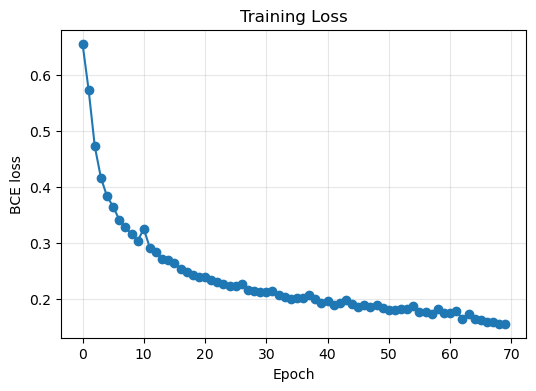

In [68]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_history = []

for epoch in range(1, 71):
    epoch_loss = 0.0
    model.train()
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    epoch_loss /= len(loader.dataset)
    loss_history.append(epoch_loss)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d}: loss={epoch_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.grid(alpha=0.3)
plt.show()

### 7. Segment the Three Images

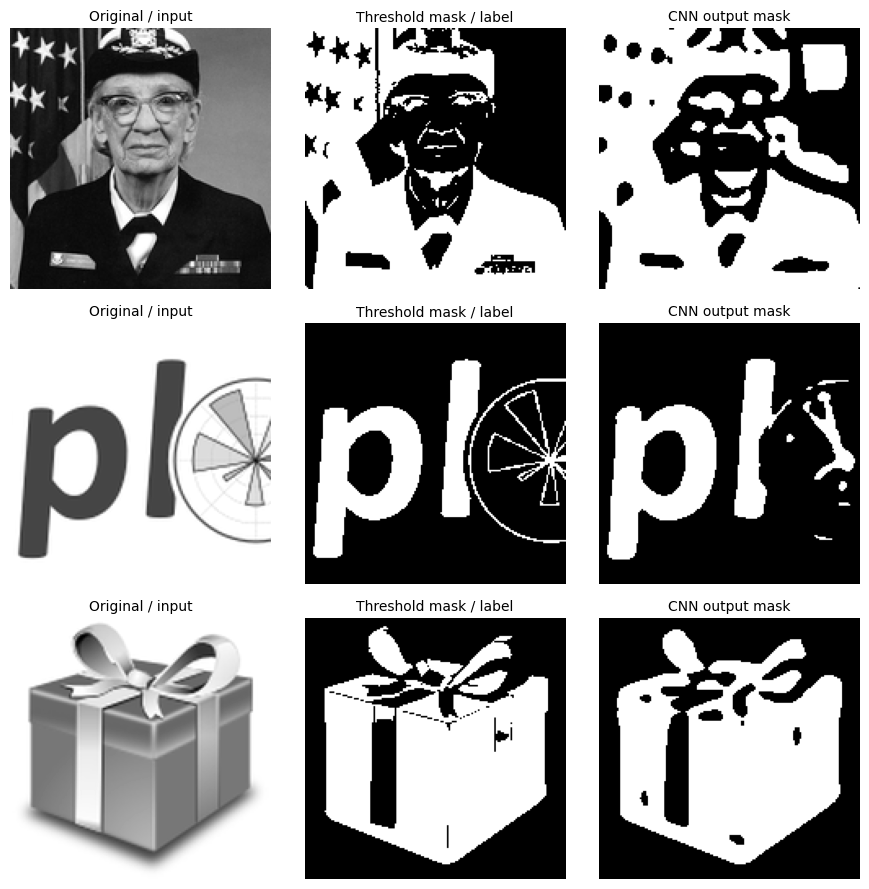

,Image,Pixel Accuracy,IoU,Dice
0,Grace Hopper portrait,0.8717,0.8025,0.8904
1,Matplotlib logo,0.9541,0.8121,0.8963
2,Present icon,0.9613,0.9218,0.9593


In [70]:
def metric_row(name, pred_mask, true_mask):
    pred_binary = pred_mask >= 0.5
    true_binary = true_mask >= 0.5
    intersection = np.logical_and(pred_binary, true_binary).sum()
    union = np.logical_or(pred_binary, true_binary).sum()
    return {
        "Image": name,
        "Pixel Accuracy": (pred_binary == true_binary).mean(),
        "IoU": intersection / max(union, 1),
        "Dice": (2 * intersection) / max(pred_binary.sum() + true_binary.sum(), 1),
    }

metric_rows = []
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
with torch.no_grad():
    for row, item in enumerate(images):
        x = torch.tensor(item["gray"][None, None, :, :], dtype=torch.float32)
        pred = torch.sigmoid(model(x)).squeeze().numpy()
        item["prediction"] = pred
        metric_rows.append(metric_row(item["title"], pred, item["mask"]))
        for col, (data, title, cmap) in enumerate([
            (item["gray"], "Original / input", "gray"),
            (item["mask"], "Threshold mask / label", "gray"),
            ((pred >= 0.5).astype(np.float32), "CNN output mask", "gray"),
        ]):
            axes[row, col].imshow(data, cmap=cmap, vmin=0, vmax=1)
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis("off")
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))